## Kunskapskontroll 1 - Del 2

### Kapitel 3 - Kodfråga 13

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('HR_Employee_Data.xlsx')
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2.0,157.0,3.0,0.0,1.0,0.0,sales,low
1,IND28133,0.80,0.86,5.0,262.0,6.0,0.0,1.0,0.0,sales,medium
2,IND07164,0.11,0.88,7.0,272.0,4.0,0.0,1.0,0.0,sales,medium
3,IND30478,0.72,0.87,5.0,223.0,5.0,0.0,1.0,0.0,sales,low
4,IND24003,0.37,0.52,2.0,159.0,3.0,0.0,1.0,0.0,sales,low


In [2]:
df.info() # Check the data types and look for missing values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  object 
 1   satisfaction_level     15000 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  float64
 4   average_montly_hours   14999 non-null  float64
 5   time_spend_company     14999 non-null  float64
 6   Work_accident          14999 non-null  float64
 7   left                   14999 non-null  float64
 8   promotion_last_5years  14999 non-null  float64
 9   Department             14999 non-null  object 
 10  salary                 14999 non-null  object 
dtypes: float64(8), object(3)
memory usage: 1.3+ MB


In [3]:
df.columns # Check the column names to identify which ones are categorical and which ones are numerical

Index(['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

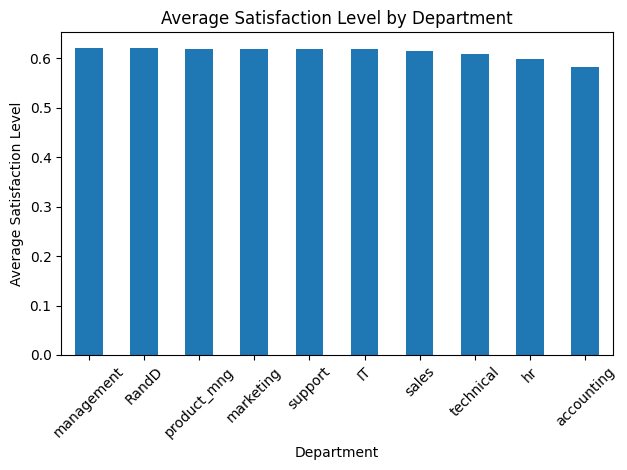

In [4]:
df.groupby('Department')['satisfaction_level'].mean().sort_values(ascending=False).plot(kind='bar') # Create a bar plot to visualize the average satisfaction level by department
plt.title('Average Satisfaction Level by Department')
plt.xlabel('Department')
plt.ylabel('Average Satisfaction Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

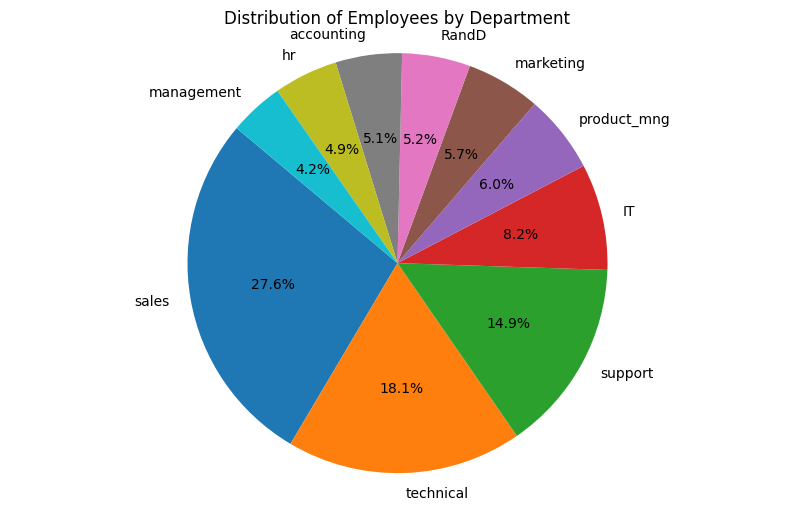

In [5]:
department_counts = df['Department'].value_counts() # Count the number of employees in each department to visualize the distribution of employees across departments
plt.figure(figsize=(10, 6))
plt.pie(department_counts, labels=department_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Employees by Department')
plt.axis('equal')
plt.show()

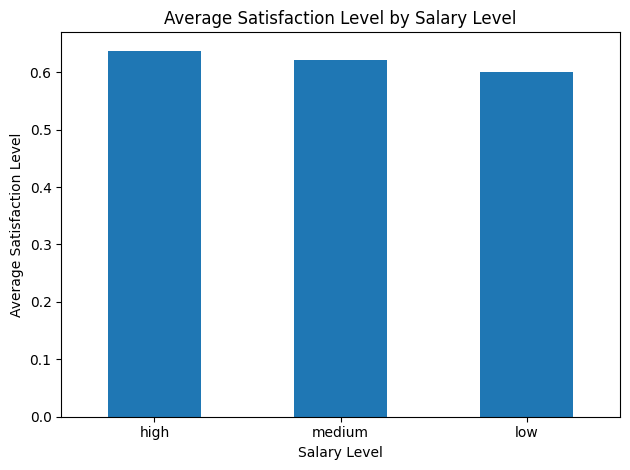

In [6]:
df.groupby('salary')['satisfaction_level'].mean().sort_values(ascending=False).plot(kind='bar') # Create a bar plot to visualize the average satisfaction level by salary level
plt.title('Average Satisfaction Level by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Average Satisfaction Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

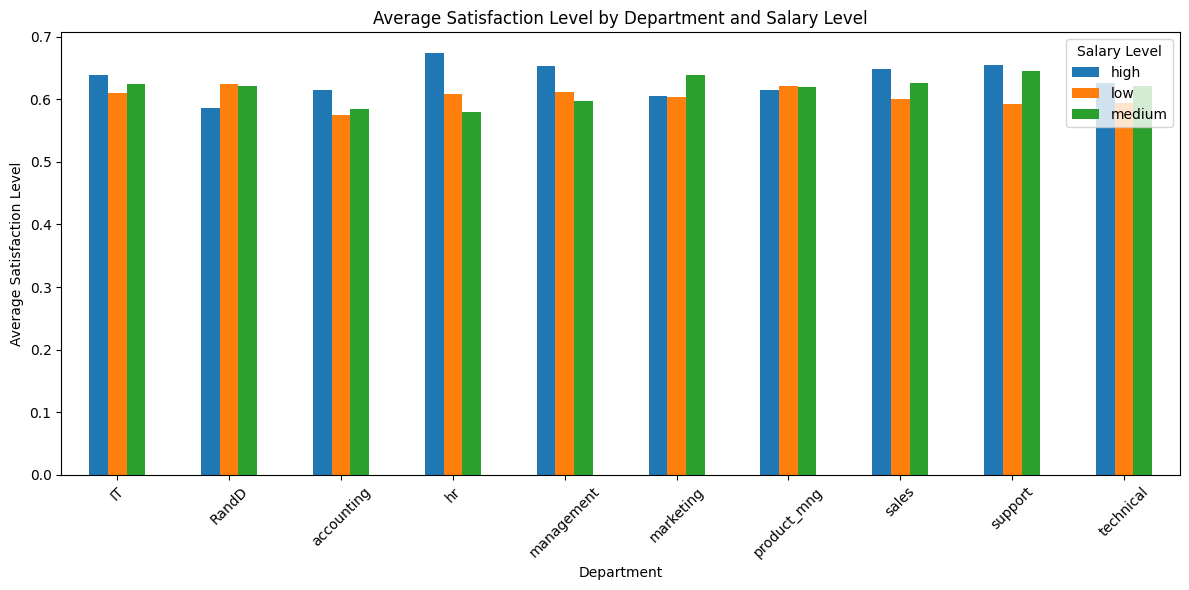

In [7]:
grouped = df.groupby(['Department', 'salary'])['satisfaction_level'].mean().unstack() # Create a grouped bar plot to visualize the average satisfaction level by department and salary level
grouped.plot(kind='bar', figsize=(12, 6))
plt.title('Average Satisfaction Level by Department and Salary Level')
plt.xlabel('Department')
plt.ylabel('Average Satisfaction Level')
plt.xticks(rotation=45)
plt.legend(title='Salary Level')
plt.tight_layout()
plt.show()

### Kaptiel 3 - kodfråga 14

In [8]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
X, y = load_diabetes(return_X_y=True, as_frame=True) # Load the diabetes dataset and split it into features (X) and target variable (y)

In [10]:
# This code is executed to check the data types and look for missing values in the features (X) and target variable (y)
print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data into training and testing sets

In [14]:
lin_reg = LinearRegression()
ran_for = RandomForestRegressor(random_state=42)

In [15]:
lin_reg.fit(X_train, y_train) # train the linear regression model on the training data
ran_for.fit(X_train, y_train) # train the random forest regressor model on the training data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
#make predictions on the test set
y_pred_lin_reg = lin_reg.predict(X_test) 
y_pred_rf = ran_for.predict(X_test) 
# Print the first 10 predictions from both models to compare their outputs
print("Linear Regression Predictions (first 10):", y_pred_lin_reg[:10]) 
print("Random Forest Predictions (first 10):", y_pred_rf[:10]) 

Linear Regression Predictions (first 10): [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]
Random Forest Predictions (first 10): [144.   171.58 150.72 253.71 107.19 123.54 239.09 219.01 153.44 184.59]


In [17]:
# Evaluate the models performance using various metrics
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error

lin_reg_r2 = r2_score(y_test, y_pred_lin_reg)
lin_reg_rmse = root_mean_squared_error(y_test, y_pred_lin_reg)
lin_reg_mae = mean_absolute_error(y_test, y_pred_lin_reg)
print(f"Linear Regression - R²: {lin_reg_r2:.2f}, RMSE: {lin_reg_rmse:.2f}, MAE: {lin_reg_mae:.2f}")

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest - R²: {rf_r2:.2f}, RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}")


Linear Regression - R²: 0.45, RMSE: 53.85, MAE: 42.79
Random Forest - R²: 0.44, RMSE: 54.33, MAE: 44.05


In [19]:
comparison_models = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "R2": [lin_reg_r2, rf_r2],
    "RMSE": [lin_reg_rmse, rf_rmse]
})

comparison_models

,Model,R2,RMSE
0,Linear Regression,0.452603,53.853446
1,Random Forest Regressor,0.442823,54.332408


In [20]:
# Create a DataFrame to compare the actual values (y_test) with the predicted values (y_pred_rf) from the random forest regressor model
comparison = pd.DataFrame({"Reality": y_test.values, "Predict": y_pred_rf})
comparison.head(10)

,Reality,Predict
0,219.0,144.00
1,70.0,171.58
2,202.0,150.72
3,230.0,253.71
4,111.0,107.19
5,84.0,123.54
6,242.0,239.09
7,272.0,219.01
8,94.0,153.44
9,96.0,184.59


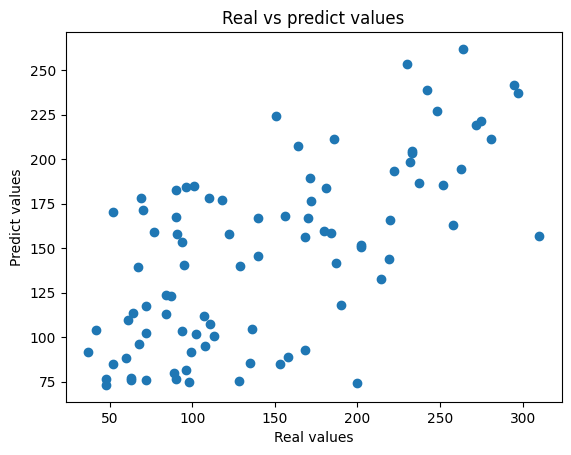

In [21]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Real values")
plt.ylabel("Predict values")
plt.title("Real vs predict values")
plt.show()

#### Man kan se att modellen inte presterar särskilt bra, då datapunkterna är relativt spridda och inte ligger nära en tydlig linje, även om man kan se en viss riktning. Detta indikerar att modellen har svårt att fånga sambandet mellan de verkliga och predikterade värdena.

### Kapitel 3 - Kodfråga 15 a)

In [ ]:
df = pd.read_csv("car_price_dataset.csv", sep=";") #semicolon is used as a separator in the csv file, so we have diffrent columns in the dataset

In [ ]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [ ]:
df.dropna()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42) # Split the training data into training and validation sets

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# Create the linear regression and decision tree regressor models
linreg = LinearRegression()
tree = DecisionTreeRegressor(random_state=42)

In [ ]:
# Train both models on the training data
linreg.fit(X_train, y_train) 
tree.fit(X_train, y_train) 

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [ ]:
# Make predictions on the validation set using both models
linreg_pred = linreg.predict(X_val)
tree_pred = tree.predict(X_val)


In [ ]:
# Compare the RMSE values to determine which model performs better on the validation set
from sklearn.metrics import root_mean_squared_error
rmse_linreg = root_mean_squared_error(y_val, linreg_pred)
rmse_tree = root_mean_squared_error(y_val, tree_pred)

print(f"Linear Regression RMSE: {rmse_linreg}")
print(f"Decision Tree Regressor RMSE: {rmse_tree}")

Linear Regression RMSE: 68.8012571689224
Decision Tree Regressor RMSE: 961.6635146973186


In [ ]:
# Compare the RMSE values to determine which model performs better on the validation set
if rmse_linreg < rmse_tree:
    best_model = LinearRegression()
    print("The linear regression model performs better on the validation set.")
else:
    best_model = DecisionTreeRegressor(random_state=42)
    print("The decision tree regressor model performs better on the validation set.")

The linear regression model performs better on the validation set.


In [ ]:
best_model.fit(X_train_full, y_train_full) # Train the best model on the full training data


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
test_pred = best_model.predict(X_test) # Make predictions on the test set using the best model
rmse_test = root_mean_squared_error(y_test, test_pred)

print(f"Test set RMSE for the best model: {rmse_test}") # Caulculate and print the RMSE for the best model on the test set to evaluate its performance on unseen data

Test set RMSE for the best model: 64.91473251912824


In [ ]:
best_model.fit(X, y) # Train the best model on the entire dataset (both training and test data) to prepare it for deployment or future predictions

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
